### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))


In [2]:
from src.preprocessing import (
    load_data,
    rename_columns,
    convert_date_columns,
    replace_never_delinquent_value,
    run_data_quality_checks,
    split_dev_validation_oot,
)

data_path = "../data/raw/dataset"

### Loading Dataset

In [3]:
loan_data = load_data(data_path)

In [4]:
loan_data = rename_columns(loan_data)
loan_data = convert_date_columns(loan_data)
loan_data = replace_never_delinquent_value(loan_data)

run_data_quality_checks(loan_data)

Duplicate rows: 0
Duplicate account-month rows: 0
INQ_12M_CNT < INQ_6M_CNT: 0
open_trades_cnt > total_trades_cnt: 0
d_dpd_max_12m_cnt < d_dpd_max_6m_cnt: 0
d_times_30dpd_12m_cnt < d_times_30dpd_6m_cnt: 0
b_curr_bal_amt > b_max_bal_12m_amt: 0
p_ontime_pay_12m_cnt > 12: 0
Invalid account dates: 0


### EDA

In [5]:
loan_data.shape

(1000000, 88)

In [6]:
pd.set_option("display.max_columns", None)
loan_data.head()

,cust_id,acct_id,appl_id,snapshot_dt,acct_open_dt,portfolio_segment_cd,age,gender_cd,marital_sts_cd,emp_sts_cd,emp_length_yrs,annual_inc_amt,residence_type_cd,state_cd,product_cd,card_type_cd,mob_cnt,credit_limit_amt,orig_credit_limit_amt,interest_rate_pct,annual_fee_amt,bureau_score,bureau_score_2,total_trades_cnt,open_trades_cnt,delinq_trades_cnt,inq_6m_cnt,inq_12m_cnt,total_debt_amt,dti_ratio,d_dpd_curr_cnt,d_dpd_max_6m_cnt,d_dpd_max_12m_cnt,d_times_30dpd_6m_cnt,d_times_30dpd_12m_cnt,d_times_60dpd_12m_cnt,d_times_90dpd_12m_cnt,d_mob_since_last_delinq_cnt,d_curr_delinq_bucket_cd,d_ever_chgoff_flag,d_cure_flag,b_curr_bal_amt,b_avg_bal_3m_amt,b_avg_bal_6m_amt,b_max_bal_12m_amt,b_min_bal_12m_amt,b_revolve_bal_amt,b_util_ratio,b_util_3m_avg_ratio,b_overlimit_flag,s_spend_1m_amt,s_spend_3m_amt,s_spend_12m_amt,s_txn_1m_cnt,s_avg_ticket_amt,s_cash_adv_amt,s_intl_txn_flag,p_min_pay_due_amt,p_actual_pay_amt,p_pay_ratio,p_ontime_pay_12m_cnt,p_days_since_last_pay_cnt,p_autopay_flag,p_nsf_12m_cnt,r_behav_score,r_application_score,r_collections_score,r_attrition_score,r_fraud_score,target,is_currently_default,default_dt,days_in_default_cnt,collateral_type_cd,collateral_value_amt,secured_flag,workout_status_cd,recovery_amt,undrawn_limit_amt,drawn_exposure_amt,ead_amt,gdp_growth_rate,unemployment_rate,hpi_index,benchmark_int_rate,macro_scenario_cd,dev_oot_flag,data_quality_flag
0,6bf470643060584b,097283fdca5b6d2d,efd1acb86480,2023-04-01,2017-07-01,CONSUMER_CARD,27,M,D,FT,0.9,60428.04,MTG,VA,PLATINUM,CONSUMER,70,4575.60,2729.90,19.06,0,698.0,704.0,29,13,0,0,1,33240.23,0.5501,0,0,0,0,0,0,0,-1.0,C,0,0,1593.68,1625.67,1907.63,2186.87,495.91,885.82,0.3483,0.3553,0,472.30,1295.03,5600.13,41,11.52,0.00,0,31.87,809.59,0.5080,9,1.0,0,0,734.0,705.0,702.0,345.0,558.0,0,0,NaT,0,NONE,0.0,0,NONE,0.0,2981.92,1593.68,0.0,2.09,4.20,101.31,5.40,BASELINE,VALIDATION,OK
1,6086a3e2eec4b57b,7c58f536e80664ff,2ee9948a5098,2024-07-24,2021-09-08,CONSUMER_CARD,26,F,M,FT,3.6,15000.00,RENT,VA,GREEN,CONSUMER,35,21283.74,14635.45,22.94,0,542.0,545.0,15,13,1,2,4,6640.80,0.4427,73,73,73,1,2,1,0,0.0,60-89,0,0,15918.11,17608.81,14783.54,22835.30,13030.36,12635.49,0.7479,0.8273,0,1370.18,3890.47,15865.89,53,25.85,98.01,0,318.36,5445.59,0.3421,10,11.0,1,1,623.0,611.0,531.0,427.0,384.0,0,0,NaT,0,NONE,0.0,0,NONE,0.0,5365.63,15918.11,0.0,1.14,5.38,105.82,4.90,UPSIDE,OUT_OF_TIME,REVIEW
2,4027d7d8e22ae6de,5ba6fefc2f6467d1,4556eec2cce1,2024-04-25,2023-03-02,CONSUMER_CARD,50,F,D,FT,0.6,40712.48,OWN,CA,CASHBACK,CONSUMER,14,2185.43,1240.30,19.23,550,843.0,825.0,18,14,0,0,0,17470.21,0.4291,0,0,0,0,0,0,0,-1.0,C,0,0,603.18,659.98,485.54,677.85,158.90,435.61,0.2760,0.3020,0,100.26,301.26,1035.27,17,5.90,0.00,0,25.00,569.34,0.9439,12,2.0,0,0,850.0,850.0,812.0,388.0,487.0,0,0,NaT,0,NONE,0.0,0,NONE,0.0,1582.25,603.18,0.0,1.39,4.95,104.63,4.69,UPSIDE,DEVELOPMENT,OK
3,4ce73a161d37692b,6a342a2d294874fc,7f13b8def759,2023-11-27,2013-05-23,CONSUMER_CARD,43,F,S,FT,0.7,91591.57,OTH,MA,GOLD,CONSUMER,128,3653.63,2807.00,14.80,95,773.0,758.0,18,14,0,0,0,51241.32,0.5595,0,0,0,0,0,0,0,-1.0,C,0,0,572.16,512.91,587.20,607.85,297.56,383.25,0.1566,0.1404,0,50.87,200.30,890.90,44,1.16,0.00,0,25.00,459.67,0.8034,12,4.0,0,0,850.0,753.0,797.0,597.0,499.0,0,0,NaT,0,NONE,0.0,0,NONE,0.0,3081.47,572.16,0.0,2.79,4.13,103.27,4.65,BASELINE,DEVELOPMENT,OK
4,5deb41f0feebd45f,3eb697a1dc906be5,f7adea4dbbcc,2023-11-27,2021-07-10,CONSUMER_CARD,22,M,M,SE,4.5,34539.30,RENT,GA,BLUE,CONSUMER,29,8631.98,6686.58,25.88,95,665.0,658.0,24,9,1,0,0,14189.01,0.4108,0,0,16,0,0,0,0,-1.0,C,0,0,4068.25,3876.01,3824.26,5086.37,1195.59,3029.19,0.4713,0.4490,0,78.53,256.24,1122.10,1,78.53,5.57,0,81.36,1507.69,0.3706,10,2.0,0,0,714.0,675.0,581.0,293.0,351.0,0,0,NaT,0,NONE,0.0,0,NONE,0.0,4563.73,4068.25,0.0,2.79,4.13,103.27,4.65,BASELINE,DEVELOPMENT,OK


In [7]:
print("Data Types")
print(loan_data.dtypes.value_counts())

Data Types
float64           41
int64             27
object            17
datetime64[ns]     3
Name: count, dtype: int64


In [8]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 88 columns):
 #   Column                       Non-Null Count    Dtype         
---  ------                       --------------    -----         
 0   cust_id                      1000000 non-null  object        
 1   acct_id                      1000000 non-null  object        
 2   appl_id                      1000000 non-null  object        
 3   snapshot_dt                  1000000 non-null  datetime64[ns]
 4   acct_open_dt                 1000000 non-null  datetime64[ns]
 5   portfolio_segment_cd         1000000 non-null  object        
 6   age                          1000000 non-null  int64         
 7   gender_cd                    1000000 non-null  object        
 8   marital_sts_cd               1000000 non-null  object        
 9   emp_sts_cd                   1000000 non-null  object        
 10  emp_length_yrs               959970 non-null   float64       
 11  annual_inc_a

In [9]:
loan_data.describe()

,snapshot_dt,acct_open_dt,age,emp_length_yrs,annual_inc_amt,mob_cnt,credit_limit_amt,orig_credit_limit_amt,interest_rate_pct,annual_fee_amt,bureau_score,bureau_score_2,total_trades_cnt,open_trades_cnt,delinq_trades_cnt,inq_6m_cnt,inq_12m_cnt,total_debt_amt,dti_ratio,d_dpd_curr_cnt,d_dpd_max_6m_cnt,d_dpd_max_12m_cnt,d_times_30dpd_6m_cnt,d_times_30dpd_12m_cnt,d_times_60dpd_12m_cnt,d_times_90dpd_12m_cnt,d_mob_since_last_delinq_cnt,d_ever_chgoff_flag,d_cure_flag,b_curr_bal_amt,b_avg_bal_3m_amt,b_avg_bal_6m_amt,b_max_bal_12m_amt,b_min_bal_12m_amt,b_revolve_bal_amt,b_util_ratio,b_util_3m_avg_ratio,b_overlimit_flag,s_spend_1m_amt,s_spend_3m_amt,s_spend_12m_amt,s_txn_1m_cnt,s_avg_ticket_amt,s_cash_adv_amt,s_intl_txn_flag,p_min_pay_due_amt,p_actual_pay_amt,p_pay_ratio,p_ontime_pay_12m_cnt,p_days_since_last_pay_cnt,p_autopay_flag,p_nsf_12m_cnt,r_behav_score,r_application_score,r_collections_score,r_attrition_score,r_fraud_score,target,is_currently_default,default_dt,days_in_default_cnt,collateral_value_amt,secured_flag,recovery_amt,undrawn_limit_amt,drawn_exposure_amt,ead_amt,gdp_growth_rate,unemployment_rate,hpi_index,benchmark_int_rate
count,1000000,1000000,1000000.000000,959970.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,969971.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,979948.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,979878.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,980068.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,22047,1000000.000000,990113.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2024-01-10 20:22:16.319999232,2016-08-17 12:44:46.176001024,40.129802,5.000305,63109.657656,90.077257,6280.746354,4711.032597,20.988163,115.612165,698.298123,697.908543,14.986779,8.998425,0.384366,1.135516,2.001232,21269.345558,0.337742,12.433005,14.901355,16.886827,0.256008,0.356482,0.100451,0.035584,-0.397466,0.000139,0.079580,2240.442115,2240.621252,2240.361840,2765.453441,1245.169942,1343.599007,0.356785,0.356835,0.002750,365.847906,1097.122376,4387.525159,39.493469,27.246421,19.882494,0.080323,50.658856,1358.072073,0.698174,10.115943,6.185208,0.350040,0.175941,716.620299,698.772413,648.840342,499.864513,505.810570,0.041416,0.022047,2023-12-18 06:54:29.342767616,0.529547,53.592796,0.031832,26.295218,4041.470492,2240.442115,126.455384,2.010299,4.465737,103.320803,5.021423
min,2023-01-31 00:00:00,2008-05-19 00:00:00,18.000000,0.000000,15000.000000,1.000000,500.000000,500.000000,9.990000,0.000000,300.000000,300.000000,1.000000,0.000000,0.000000,0.000000,0.000000,750.080000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.370000,4.260000,18.670000,0.000000,0.030000,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,301.000000,300.000000,37.000000,1.000000,0.000000,0.000000,2022-09-27 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.850000,3.590000,100.360000,4.480000
25%,2023-06-30 00:00:00,2012-12-24 00:00:00,32.000000,1.400000,37300.985000,45.000000,3066.540000,2213.950000,18.310000,0.000000,639.000000,638.000000,8.000000,4.000000,0.000000,0.000000,0.000000,9095.387500,0.194000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,688.660000

In [10]:
missing_summary = loan_data.isnull().sum().sort_values(ascending=False)
missing_summary.head(10)

default_dt                     977953
emp_length_yrs                  40030
bureau_score_2                  30029
d_mob_since_last_delinq_cnt     20122
dti_ratio                       20052
p_days_since_last_pay_cnt       19932
collateral_value_amt             9887
cust_id                             0
p_actual_pay_amt                    0
p_nsf_12m_cnt                       0
dtype: int64

### LGD Population

In [11]:
# filtering defaulted accounts
lgd_population= loan_data[loan_data['is_currently_default'] == 1].copy()

In [12]:
print(f"Full dataset shape: {loan_data.shape}")
print(f"LGD population: {lgd_population.shape}")

Full dataset shape: (1000000, 88)
LGD population: (22047, 88)


In [13]:
# lgd target creation
lgd_population['lgd']= 1 - (lgd_population['recovery_amt']/ lgd_population['ead_amt'])
lgd_population['lgd']= lgd_population['lgd'].clip(0,1)

In [14]:
lgd_population.drop(columns= 'is_currently_default', inplace=True)

In [15]:
lgd_population['lgd'].describe()

count    22047.000000
mean         0.793654
std          0.111088
min          0.015200
25%          0.733518
50%          0.804843
75%          0.869178
max          1.000000
Name: lgd, dtype: float64

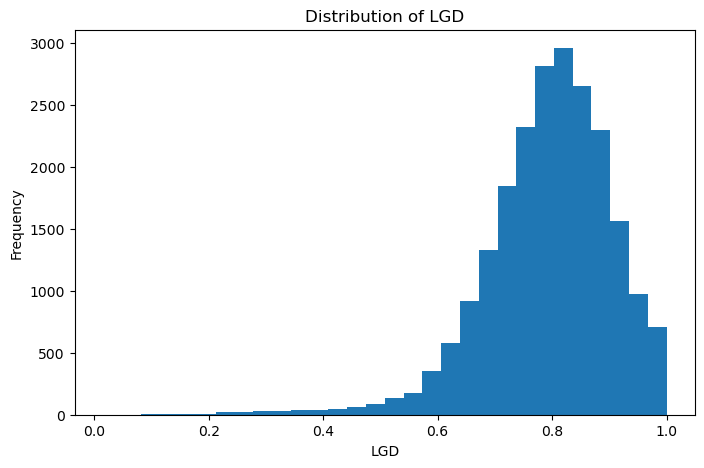

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(lgd_population["lgd"].dropna(), bins=30)
plt.title("Distribution of LGD")
plt.xlabel("LGD")
plt.ylabel("Frequency")
plt.show()

In [17]:
print(
    f"LGD range: {lgd_population['lgd'].min():.4f} "
    f"to {lgd_population['lgd'].max():.4f}"
)

LGD range: 0.0152 to 1.0000


In [18]:
(lgd_population["ead_amt"] == 0).sum()

0

### Development, Validation & OOT Split

In [19]:
development_data, validation_data, oot_data = split_dev_validation_oot(lgd_population)

# preserve OOT identifiers for saving predictions later
oot_ids = oot_data[
    ["acct_id", "snapshot_dt"]
].copy()

print(f"Development Shape: {development_data.shape}")
print(f"Validation Shape:  {validation_data.shape}")
print(f"OOT Shape:         {oot_data.shape}")

Development Shape: (13514, 88)
Validation Shape:  (3027, 88)
OOT Shape:         (5506, 88)


In [20]:
development_data.head()

,cust_id,acct_id,appl_id,snapshot_dt,acct_open_dt,portfolio_segment_cd,age,gender_cd,marital_sts_cd,emp_sts_cd,emp_length_yrs,annual_inc_amt,residence_type_cd,state_cd,product_cd,card_type_cd,mob_cnt,credit_limit_amt,orig_credit_limit_amt,interest_rate_pct,annual_fee_amt,bureau_score,bureau_score_2,total_trades_cnt,open_trades_cnt,delinq_trades_cnt,inq_6m_cnt,inq_12m_cnt,total_debt_amt,dti_ratio,d_dpd_curr_cnt,d_dpd_max_6m_cnt,d_dpd_max_12m_cnt,d_times_30dpd_6m_cnt,d_times_30dpd_12m_cnt,d_times_60dpd_12m_cnt,d_times_90dpd_12m_cnt,d_mob_since_last_delinq_cnt,d_curr_delinq_bucket_cd,d_ever_chgoff_flag,d_cure_flag,b_curr_bal_amt,b_avg_bal_3m_amt,b_avg_bal_6m_amt,b_max_bal_12m_amt,b_min_bal_12m_amt,b_revolve_bal_amt,b_util_ratio,b_util_3m_avg_ratio,b_overlimit_flag,s_spend_1m_amt,s_spend_3m_amt,s_spend_12m_amt,s_txn_1m_cnt,s_avg_ticket_amt,s_cash_adv_amt,s_intl_txn_flag,p_min_pay_due_amt,p_actual_pay_amt,p_pay_ratio,p_ontime_pay_12m_cnt,p_days_since_last_pay_cnt,p_autopay_flag,p_nsf_12m_cnt,r_behav_score,r_application_score,r_collections_score,r_attrition_score,r_fraud_score,target,default_dt,days_in_default_cnt,collateral_type_cd,collateral_value_amt,secured_flag,workout_status_cd,recovery_amt,undrawn_limit_amt,drawn_exposure_amt,ead_amt,gdp_growth_rate,unemployment_rate,hpi_index,benchmark_int_rate,macro_scenario_cd,dev_oot_flag,data_quality_flag,lgd
20,4ba8177ce0fa94e8,1ef9558170bc0e73,f8ba82f44a9e,2024-01-26,2021-05-11,SMALL_BUS_CARD,46,M,M,RET,8.7,15000.00,RENT,IL,GREEN,BUSINESS,33,1855.36,1139.81,20.99,250,513.0,502.0,1,1,1,2,4,8349.39,0.5566,101,101,101,1,1,1,1,0.0,90-119,0,1,1363.88,1294.01,1177.90,1697.42,855.75,477.56,0.7351,0.6974,0,42.74,100.37,412.02,60,0.71,5.31,0,27.28,576.65,0.4228,9,17.0,1,0,589.0,567.0,430.0,471.0,444.0,0,2024-01-15,11,NONE,0.0,0,NONE,263.91,491.48,1363.88,1694.15,2.03,4.35,103.31,4.62,DOWNSIDE,DEVELOPMENT,OK,0.844223
289,26ffdd03c36d3eef,081a89a9d6de404d,70d0f85218a7,2023-12-27,2013-12-19,CONSUMER_CARD,52,F,M,FT,NaN,94771.46,OWN,TX,CASHBACK,CONSUMER,122,4877.75,3181.22,26.90,0,388.0,353.0,13,7,3,6,12,45096.38,0.4758,147,147,147,3,3,1,1,0.0,120-149,0,0,4108.53,4487.36,4600.75,5094.83,3159.90,3126.45,0.8423,0.9200,0,42.22,164.58,577.47,65,0.65,113.24,0,82.17,0.00,0.0000,3,17.0,1,1,400.0,387.0,300.0,546.0,409.0,1,2023-10-31,57,NONE,0.0,0,LEGAL,855.40,769.22,4108.53,4555.83,2.37,4.30,103.37,4.48,BASELINE,DEVELOPMENT,OK,0.812241
428,41e48cf3260e7560,1d566538731d9be0,62b0f0782f37,2023-01-31,2017-09-29,SMALL_BUS_CARD,32,F,S,FT,11.7,59328.99,RENT,IL,CASHBACK,BUSINESS,65,17880.47,15056.16,21.00,550,475.0,496.0,1,1,1,4,5,31692.27,0.5342,132,132,132,1,1,1,1,0.0,120-149,0,0,8587.99,7824.37,7575.81,9772.60,4583.71,3534.77,0.4803,0.4376,0,454.55,1075.34,4778.17,15,30.30,38.82,0,171.76,2153.01,0.2507,6,12.0,1,0,551.0,507.0,451.0,613.0,619.0,0,2022-12-20,42,NONE,0.0,0,NONE,2395.19,9292.48,8587.99,13633.81,2.15,4.23,100.55,5.73,BASELINE,DEVELOPMENT,OK,0.824320
463,2549925c9db6ecf0,376bb5304454298d,ab3de1e2b13e,2023-11-27,2023-03-02,CONSUMER_CARD,46,F,S,FT,2.3,34015.59,RENT,WA,CASHBACK,CONSUMER,9,1965.26,1279.77,21.27,95,445.0,463.0,22,15,2,5,11,11908.33,0.3501,139,139,139,1,1,1,1,0.0,120-149,0,0,1417.94,1261.57,1662.06,1874.70,452.10,525.36,0.7215,0.6419,0,133.62,332.52,1187.98,15,8.91,4.24,0,28.36,295.36,0.2083,7,8.0,0,4,512.0,492.0,413.0,574.0,630.0,0,2023-10-09,49,NONE,0.0,0,NONE,255.94,547.32,1417.94,1806.92,2.79,4.13,103.27,4.65,BASELINE,DEVELOPMENT,OK,0.858356
486,3cf0945775b61212,767e6b3c3ed08ac0,e4316e5afee9,2023-09-28,2022-06-05,CONSUMER_CARD,48,F,M,SE,1.8,56925.30,OWN,NC,PLATINUM,CONSUMER,16,5456.00,3360.83,19.56,95,460.0,439.0,2,1,2,4,7,28763.98,0.5053,115,142,142,1,2,1,1,0.0,90-119,0,0,3442.19,3606.04,3790.81,4858.84,1762.48,1130.89,0.6309,0.6609,0,720.10,1758.01,6747.89,49,14.70,143.22,1,68.84,1362.42,0.3958,6,7.0,1,3,512.0,505.0,416.0,637.0,803.0,0,2023-09-03,25,NONE,0.0,0,REPAYMENT_PLAN,344.56,2013.81,3442.19,4816.62,2.96,3.59,102.08,4.88,BASELINE,DEVELOPMENT,OK,0.928464


In [21]:
print("Development")
print(development_data["lgd"].describe())

print("\nValidation")
print(validation_data["lgd"].describe())

print("\nOOT")
print(oot_data["lgd"].describe())

Development
count    13514.000000
mean         0.792519
std          0.110932
min          0.015200
25%          0.732829
50%          0.803827
75%          0.867464
max          1.000000
Name: lgd, dtype: float64

Validation
count    3027.000000
mean        0.794602
std         0.110255
min         0.073831
25%         0.734432
50%         0.803967
75%         0.870768
max         1.000000
Name: lgd, dtype: float64

OOT
count    5506.000000
mean        0.795919
std         0.111906
min         0.086024
25%         0.734482
50%         0.807248
75%         0.872442
max         1.000000
Name: lgd, dtype: float64


### Feature Selection & Data Preparation

In [22]:
# dropping variables not used for LGD modeling
drop_columns = [
    'dev_oot_flag',
    "target",
    'snapshot_dt',
    'acct_open_dt',

    # IDs
    "cust_id",
    "acct_id",
    "appl_id",

    # risk scores
    "r_behav_score",
    "r_application_score",
    "r_collections_score",
    "r_attrition_score",
    "r_fraud_score",

    # default outcome information
    "default_dt",
    "days_in_default_cnt",
    "recovery_amt",
    "workout_status_cd",

    # EAD target variables
    "ead_amt",
    "drawn_exposure_amt",
    "undrawn_limit_amt",

    # ECL variables
    "macro_scenario_cd",
    "gdp_growth_rate",
    "unemployment_rate",
    "hpi_index",
    "benchmark_int_rate",

]

development_data = development_data.drop(columns=drop_columns)
validation_data = validation_data.drop(columns=drop_columns)
oot_data = oot_data.drop(columns=drop_columns)

print(development_data.shape)
print(validation_data.shape)
print(oot_data.shape)


(13514, 64)
(3027, 64)
(5506, 64)


In [23]:
# separate predictors and target
X_train = development_data.drop(columns="lgd")
y_train = development_data["lgd"]

X_validation = validation_data.drop(columns="lgd")
y_validation = validation_data["lgd"]

X_oot = oot_data.drop(columns="lgd")
y_oot = oot_data["lgd"]


In [24]:
print(X_train.shape, y_train.shape)
print(X_validation.shape, y_validation.shape)
print(X_oot.shape, y_oot.shape)

(13514, 63) (13514,)
(3027, 63) (3027,)
(5506, 63) (5506,)


### Missing Value Summary

In [25]:
missing_summary = X_train.isnull().sum().sort_values(ascending=False)

missing_summary = missing_summary[missing_summary > 0]

missing_summary

emp_length_yrs                 566
bureau_score_2                 402
p_days_since_last_pay_cnt      279
dti_ratio                      272
d_mob_since_last_delinq_cnt    249
collateral_value_amt           129
dtype: int64

In [26]:
# emp_length_yrs
X_train["emp_length_yrs"].describe()


count    12948.000000
mean         4.956302
std          4.936614
min          0.000000
25%          1.400000
50%          3.400000
75%          6.900000
max         40.000000
Name: emp_length_yrs, dtype: float64

In [27]:
# imputing the missing values
emp_length_median = X_train["emp_length_yrs"].median()

X_train["emp_length_yrs"] = X_train["emp_length_yrs"].fillna(emp_length_median)
X_validation["emp_length_yrs"] = X_validation["emp_length_yrs"].fillna(emp_length_median)
X_oot["emp_length_yrs"] = X_oot["emp_length_yrs"].fillna(emp_length_median)


In [28]:
print(X_train["emp_length_yrs"].isna().sum())
print(X_validation["emp_length_yrs"].isna().sum())
print(X_oot["emp_length_yrs"].isna().sum())

0
0
0


In [29]:
# bureau_score_2
X_train["bureau_score_2"].describe()

count    13112.000000
mean       525.285921
std         60.814474
min        300.000000
25%        486.000000
50%        526.000000
75%        567.000000
max        739.000000
Name: bureau_score_2, dtype: float64

In [30]:
bureau_score_2_median = X_train["bureau_score_2"].median()

X_train["bureau_score_2"] = X_train["bureau_score_2"].fillna(bureau_score_2_median)
X_validation["bureau_score_2"] = X_validation["bureau_score_2"].fillna(bureau_score_2_median)
X_oot["bureau_score_2"] = X_oot["bureau_score_2"].fillna(bureau_score_2_median)


In [31]:
print(X_train["bureau_score_2"].isna().sum())
print(X_validation["bureau_score_2"].isna().sum())
print(X_oot["bureau_score_2"].isna().sum())

0
0
0


In [32]:
# p_days_since_last_pay_cnt
X_train["p_days_since_last_pay_cnt"].describe()

count    13235.000000
mean        11.004307
std          5.156716
min          1.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         50.000000
Name: p_days_since_last_pay_cnt, dtype: float64

In [33]:
p_days_since_last_pay_median = X_train["p_days_since_last_pay_cnt"].median()

X_train["p_days_since_last_pay_cnt"] = X_train["p_days_since_last_pay_cnt"].fillna(p_days_since_last_pay_median)
X_validation["p_days_since_last_pay_cnt"] = X_validation["p_days_since_last_pay_cnt"].fillna(p_days_since_last_pay_median)
X_oot["p_days_since_last_pay_cnt"] = X_oot["p_days_since_last_pay_cnt"].fillna(p_days_since_last_pay_median)


In [34]:
print(X_train["p_days_since_last_pay_cnt"].isna().sum())
print(X_validation["p_days_since_last_pay_cnt"].isna().sum())
print(X_oot["p_days_since_last_pay_cnt"].isna().sum())

0
0
0


In [35]:
# dti_ratio
X_train["dti_ratio"].describe()

count    13242.000000
mean         0.393580
std          0.193525
min          0.053900
25%          0.227100
50%          0.393200
75%          0.559500
max          0.825200
Name: dti_ratio, dtype: float64

In [36]:
dti_ratio_median = X_train["dti_ratio"].median()

X_train["dti_ratio"] = X_train["dti_ratio"].fillna(dti_ratio_median)
X_validation["dti_ratio"] = X_validation["dti_ratio"].fillna(dti_ratio_median)
X_oot["dti_ratio"] = X_oot["dti_ratio"].fillna(dti_ratio_median)


In [37]:
print(X_train["dti_ratio"].isna().sum())
print(X_validation["dti_ratio"].isna().sum())
print(X_oot["dti_ratio"].isna().sum())

0
0
0


In [38]:
# d_mob_since_last_delinq_cnt
d_mob_since_last_delinq_median = X_train.loc[
    X_train["d_times_30dpd_12m_cnt"] > 0,
    "d_mob_since_last_delinq_cnt"
].median()


In [39]:
# training
X_train.loc[
    (X_train["d_mob_since_last_delinq_cnt"].isna()) &
    (X_train["d_times_30dpd_12m_cnt"] == 0),
    "d_mob_since_last_delinq_cnt"
] = -1

X_train["d_mob_since_last_delinq_cnt"] = X_train[
    "d_mob_since_last_delinq_cnt"
].fillna(d_mob_since_last_delinq_median)


# validation
X_validation.loc[
    (X_validation["d_mob_since_last_delinq_cnt"].isna()) &
    (X_validation["d_times_30dpd_12m_cnt"] == 0),
    "d_mob_since_last_delinq_cnt"
] = -1

X_validation["d_mob_since_last_delinq_cnt"] = X_validation[
    "d_mob_since_last_delinq_cnt"
].fillna(d_mob_since_last_delinq_median)


# oot
X_oot.loc[
    (X_oot["d_mob_since_last_delinq_cnt"].isna()) &
    (X_oot["d_times_30dpd_12m_cnt"] == 0),
    "d_mob_since_last_delinq_cnt"
] = -1

X_oot["d_mob_since_last_delinq_cnt"] = X_oot[
    "d_mob_since_last_delinq_cnt"
].fillna(d_mob_since_last_delinq_median)

In [40]:
# collateral_value_amt
X_train["collateral_value_amt"].describe()

count    13385.000000
mean       111.248350
std        852.283842
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      23368.040000
Name: collateral_value_amt, dtype: float64

In [41]:
X_train["secured_flag"].value_counts(dropna=False)

secured_flag
0    13065
1      449
Name: count, dtype: int64

In [42]:
pd.crosstab(
    X_train["secured_flag"],
    X_train["collateral_value_amt"].isna()
)

collateral_value_amt,False,True
secured_flag,,
0,12939,126
1,446,3


In [43]:
X_train.groupby("secured_flag")["collateral_value_amt"].describe()

,count,mean,std,min,25%,50%,75%,max
secured_flag,,,,,,,,
0,12939.0,0.000000,0.00000,0.00,0.0000,0.000,0.0000,0.00
1,446.0,3338.697668,3323.76889,287.14,1204.9825,2167.025,4158.3775,23368.04


In [44]:
# Median collateral value for secured loans
secured_median = X_train.loc[
    X_train["secured_flag"] == 1,
    "collateral_value_amt"
].median()

# Training
X_train.loc[
    (X_train["secured_flag"] == 0) &
    (X_train["collateral_value_amt"].isna()),
    "collateral_value_amt"
] = 0

X_train.loc[
    (X_train["secured_flag"] == 1) &
    (X_train["collateral_value_amt"].isna()),
    "collateral_value_amt"
] = secured_median

# Validation
X_validation.loc[
    (X_validation["secured_flag"] == 0) &
    (X_validation["collateral_value_amt"].isna()),
    "collateral_value_amt"
] = 0

X_validation.loc[
    (X_validation["secured_flag"] == 1) &
    (X_validation["collateral_value_amt"].isna()),
    "collateral_value_amt"
] = secured_median

# OOT
X_oot.loc[
    (X_oot["secured_flag"] == 0) &
    (X_oot["collateral_value_amt"].isna()),
    "collateral_value_amt"
] = 0

X_oot.loc[
    (X_oot["secured_flag"] == 1) &
    (X_oot["collateral_value_amt"].isna()),
    "collateral_value_amt"
] = secured_median

In [45]:
print(X_train.isnull().sum().sum())
print(X_validation.isnull().sum().sum())
print(X_oot.isnull().sum().sum())

0
0
0


### Feature Selection

In [46]:
# separating numerical and categorical features
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numerical features: 52
Categorical features: 11


In [47]:
categorical_features

['portfolio_segment_cd',
 'gender_cd',
 'marital_sts_cd',
 'emp_sts_cd',
 'residence_type_cd',
 'state_cd',
 'product_cd',
 'card_type_cd',
 'd_curr_delinq_bucket_cd',
 'collateral_type_cd',
 'data_quality_flag']

In [48]:
numerical_features

['age',
 'emp_length_yrs',
 'annual_inc_amt',
 'mob_cnt',
 'credit_limit_amt',
 'orig_credit_limit_amt',
 'interest_rate_pct',
 'annual_fee_amt',
 'bureau_score',
 'bureau_score_2',
 'total_trades_cnt',
 'open_trades_cnt',
 'delinq_trades_cnt',
 'inq_6m_cnt',
 'inq_12m_cnt',
 'total_debt_amt',
 'dti_ratio',
 'd_dpd_curr_cnt',
 'd_dpd_max_6m_cnt',
 'd_dpd_max_12m_cnt',
 'd_times_30dpd_6m_cnt',
 'd_times_30dpd_12m_cnt',
 'd_times_60dpd_12m_cnt',
 'd_times_90dpd_12m_cnt',
 'd_mob_since_last_delinq_cnt',
 'd_ever_chgoff_flag',
 'd_cure_flag',
 'b_curr_bal_amt',
 'b_avg_bal_3m_amt',
 'b_avg_bal_6m_amt',
 'b_max_bal_12m_amt',
 'b_min_bal_12m_amt',
 'b_revolve_bal_amt',
 'b_util_ratio',
 'b_util_3m_avg_ratio',
 'b_overlimit_flag',
 's_spend_1m_amt',
 's_spend_3m_amt',
 's_spend_12m_amt',
 's_txn_1m_cnt',
 's_avg_ticket_amt',
 's_cash_adv_amt',
 's_intl_txn_flag',
 'p_min_pay_due_amt',
 'p_actual_pay_amt',
 'p_pay_ratio',
 'p_ontime_pay_12m_cnt',
 'p_days_since_last_pay_cnt',
 'p_autopay_flag'

In [49]:
# correlation analysis
correlation_matrix= X_train[numerical_features].corr()

correlation_matrix.head()

,age,emp_length_yrs,annual_inc_amt,mob_cnt,credit_limit_amt,orig_credit_limit_amt,interest_rate_pct,annual_fee_amt,bureau_score,bureau_score_2,total_trades_cnt,open_trades_cnt,delinq_trades_cnt,inq_6m_cnt,inq_12m_cnt,total_debt_amt,dti_ratio,d_dpd_curr_cnt,d_dpd_max_6m_cnt,d_dpd_max_12m_cnt,d_times_30dpd_6m_cnt,d_times_30dpd_12m_cnt,d_times_60dpd_12m_cnt,d_times_90dpd_12m_cnt,d_mob_since_last_delinq_cnt,d_ever_chgoff_flag,d_cure_flag,b_curr_bal_amt,b_avg_bal_3m_amt,b_avg_bal_6m_amt,b_max_bal_12m_amt,b_min_bal_12m_amt,b_revolve_bal_amt,b_util_ratio,b_util_3m_avg_ratio,b_overlimit_flag,s_spend_1m_amt,s_spend_3m_amt,s_spend_12m_amt,s_txn_1m_cnt,s_avg_ticket_amt,s_cash_adv_amt,s_intl_txn_flag,p_min_pay_due_amt,p_actual_pay_amt,p_pay_ratio,p_ontime_pay_12m_cnt,p_days_since_last_pay_cnt,p_autopay_flag,p_nsf_12m_cnt,collateral_value_amt,secured_flag
age,1.000000,0.002505,0.007668,0.010987,-0.007030,-0.006461,0.005959,-0.000333,-0.007466,-0.006951,-0.003726,-0.008019,0.003704,-0.002756,-0.003834,0.017156,0.006336,0.015112,0.017542,0.015498,-0.002524,-0.006715,0.007387,0.000595,NaN,-0.006608,-0.000174,-0.005380,-0.006688,-0.005449,-0.004574,-0.004454,-0.005759,-0.001141,-0.004221,-0.005785,-0.008435,-0.005679,-0.006914,0.007170,-0.007361,-0.013920,-0.008984,-0.004970,-0.010114,-0.005534,-0.003651,-0.000882,-0.021310,0.007401,0.012885,0.007503
emp_length_yrs,0.002505,1.000000,0.001178,-0.003166,-0.001445,-0.007739,-0.000153,0.006439,-0.003552,-0.004899,0.006366,0.009606,0.004913,0.002008,-0.000861,0.008298,0.011066,0.008702,0.003619,0.003329,0.003788,0.012902,-0.005704,0.010185,NaN,0.006343,0.014599,0.001919,0.003081,0.001357,0.001828,0.004894,-0.001841,0.012265,0.015126,0.008716,0.002804,0.001083,0.000381,-0.005786,0.016446,0.001759,0.007876,0.001850,0.000121,0.004844,0.014609,0.000550,-0.000271,0.006152,-0.007829,-0.007846
annual_inc_amt,0.007668,0.001178,1.000000,0.009806,-0.006262,-0.006879,0.011989,-0.006373,0.048828,0.048246,0.004887,0.004989,-0.016780,-0.016968,-0.026771,0.723687,-0.002889,-0.033763,-0.034083,-0.030317,0.001841,0.002450,-0.002139,0.007282,NaN,-0.017473,0.008799,-0.019133,-0.019737,-0.017962,-0.016429,-0.021029,-0.018636,-0.033580,-0.034354,-0.018447,0.023846,0.021871,0.021732,0.005116,-0.002522,-0.022755,-0.000463,-0.019198,0.007183,0.031512,0.031762,-0.029911,0.009320,-0.014894,-0.014295,-0.005686
mob_cnt,0.010987,-0.003166,0.009806,1.000000,0.006681,0.005461,0.012190,-0.013817,-0.013055,-0.009621,0.002249,-0.003015,0.014918,0.009632,0.007332,0.010890,0.008448,-0.009614,-0.011261,-0.007391,-0.003075,0.006884,0.009225,0.009796,NaN,-0.019179,0.002212,0.010943,0.011784,0.011573,0.011222,0.012261,0.010772,0.006942,0.008349,0.008599,-0.001327,-0.001296,-0.001415,-0.016283,0.004061,0.012991,0.007257,0.010977,0.000274,-0.005234,-0.007014,0.011700,-0.007930,0.017913,0.020488,0.011360
credit_limit_amt,-0.007030,-0.001445,-0.006262,0.006681,1.000000,0.954405,-0.011651,0.002282,-0.014255,-0.016867,-0.003508,-0.009022,0.008677,0.001000,0.010129,-0.014659,-0.018373,0.006340,0.000633,0.000836,-0.007864,-0.003420,0.007964,0.005119,NaN,-0.004919,0.003232,0.924551,0.917322,0.908767,0.916290,0.837242,0.842554,0.001082,0.001746,0.001072,0.013180,0.011029,0.012570,-0.006709,0.008118,-0.002164,0.004379,0.923725,0.712715,-0.006960,0.000339,-0.001903,0.009822,-0.001370,0.097137,-0.003467


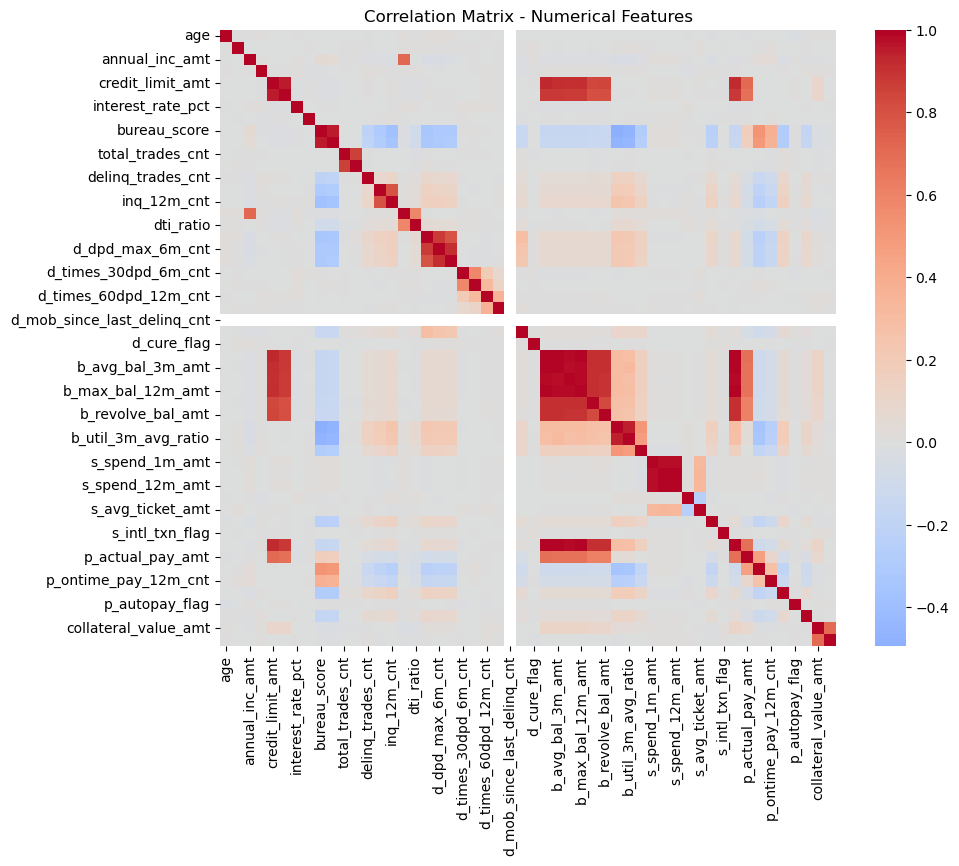

In [50]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix - Numerical Features")
plt.show()

In [51]:
corr_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]


In [52]:
high_corr = (
    corr_pairs[
        corr_pairs["correlation"].abs() >= 0.80
    ]
    .sort_values(by="correlation", key=abs, ascending=False)
)

high_corr

,feature_1,feature_2,correlation
990,b_curr_bal_amt,p_min_pay_due_amt,0.999523
1170,s_spend_3m_amt,s_spend_12m_amt,0.994226
975,b_curr_bal_amt,b_avg_bal_3m_amt,0.991379
1013,b_avg_bal_3m_amt,p_min_pay_due_amt,0.990911
977,b_curr_bal_amt,b_max_bal_12m_amt,0.990122
1056,b_max_bal_12m_amt,p_min_pay_due_amt,0.989630
1000,b_avg_bal_3m_amt,b_max_bal_12m_amt,0.986538
1022,b_avg_bal_6m_amt,b_max_bal_12m_amt,0.984867
976,b_curr_bal_amt,b_avg_bal_6m_amt,0.984570
1035,b_avg_bal_6m_amt,p_min_pay_due_amt,0.984087


In [53]:
# variables removed based on correlation analysis
drop_columns_corr = [

    # Credit limits
    "orig_credit_limit_amt",
    "credit_limit_amt",

    # Bureau
    "bureau_score_2",

    # Balance
    "b_avg_bal_3m_amt",
    "b_avg_bal_6m_amt",
    "b_max_bal_12m_amt",
    "b_min_bal_12m_amt",
    "b_revolve_bal_amt",

    # Utilization
    "b_util_3m_avg_ratio",

    # Spending
    "s_spend_1m_amt",
    "s_spend_12m_amt",

    # Payments
    "p_min_pay_due_amt",

    # Delinquency
    "d_dpd_max_6m_cnt",

    # Trade counts
    "total_trades_cnt",
]

In [54]:
X_train = X_train.drop(columns=drop_columns_corr)
X_validation = X_validation.drop(columns=drop_columns_corr)
X_oot = X_oot.drop(columns=drop_columns_corr)

print(X_train.shape)
print(X_validation.shape)
print(X_oot.shape)


(13514, 49)
(3027, 49)
(5506, 49)


In [55]:
numerical_features = [
    col for col in numerical_features
    if col in X_train.columns
]

categorical_features = [
    col for col in categorical_features
    if col in X_train.columns
]

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numerical features: 38
Categorical features: 11


In [56]:
# recalculating correlation matrix 
correlation_matrix = X_train[numerical_features].corr()

corr_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

In [57]:
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

high_corr = (
    corr_pairs[
        corr_pairs["correlation"].abs() >= 0.80
    ]
    .sort_values(by="correlation", key=abs, ascending=False)
)

high_corr

,feature_1,feature_2,correlation


In [58]:
# checking unique categories
X_train[categorical_features].nunique().sort_values()

data_quality_flag           2
portfolio_segment_cd        3
gender_cd                   3
card_type_cd                3
marital_sts_cd              4
residence_type_cd           4
d_curr_delinq_bucket_cd     4
collateral_type_cd          4
emp_sts_cd                  5
product_cd                  5
state_cd                   15
dtype: int64

In [59]:
for col in categorical_features:
    print(f"\n{col}")
    print(X_train[col].value_counts(dropna=False))


portfolio_segment_cd
portfolio_segment_cd
CONSUMER_CARD     9741
SMALL_BUS_CARD    2688
CORPORATE_CARD    1085
Name: count, dtype: int64

gender_cd
gender_cd
M    6490
F    6490
U     534
Name: count, dtype: int64

marital_sts_cd
marital_sts_cd
M    6099
S    5146
D    1612
W     657
Name: count, dtype: int64

emp_sts_cd
emp_sts_cd
FT     8479
SE     1819
PT     1370
RET    1155
UN      691
Name: count, dtype: int64

residence_type_cd
residence_type_cd
MTG     5699
RENT    4340
OWN     2963
OTH      512
Name: count, dtype: int64

state_cd
state_cd
GA    968
CA    956
NJ    945
PA    927
WA    918
TX    908
OH    903
NC    899
IL    895
MI    883
VA    871
NY    869
FL    860
MA    859
AZ    853
Name: count, dtype: int64

product_cd
product_cd
BLUE        4037
GREEN       3399
GOLD        2704
CASHBACK    2041
PLATINUM    1333
Name: count, dtype: int64

card_type_cd
card_type_cd
CONSUMER     9741
BUSINESS     2688
CORPORATE    1085
Name: count, dtype: int64

d_curr_delinq_bucket_cd
d_c

### Feature Encoding

In [60]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

encoder_features = categorical_features.copy()

encoder.fit(X_train[categorical_features])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infre

In [61]:
# transforming all datasets
X_train_encoded = encoder.transform(X_train[categorical_features])
X_validation_encoded = encoder.transform(X_validation[categorical_features])
X_oot_encoded = encoder.transform(X_oot[categorical_features])

In [62]:
# getting encoded column names
encoded_columns = encoder.get_feature_names_out(categorical_features)

In [63]:
# converting to dataframes
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index,
)

X_validation_encoded = pd.DataFrame(
    X_validation_encoded,
    columns=encoded_columns,
    index=X_validation.index,
)

X_oot_encoded = pd.DataFrame(
    X_oot_encoded,
    columns=encoded_columns,
    index=X_oot.index,
)


In [64]:
# combining numerical features
X_train = pd.concat(
    [
        X_train[numerical_features],
        X_train_encoded,
    ],
    axis=1,
)

X_validation = pd.concat(
    [
        X_validation[numerical_features],
        X_validation_encoded,
    ],
    axis=1,
)

X_oot = pd.concat(
    [
        X_oot[numerical_features],
        X_oot_encoded,
    ],
    axis=1,
)

In [65]:
print(X_train.shape)
print(X_validation.shape)
print(X_oot.shape)

X_train.head()

(13514, 79)
(3027, 79)
(5506, 79)


,age,emp_length_yrs,annual_inc_amt,mob_cnt,interest_rate_pct,annual_fee_amt,bureau_score,open_trades_cnt,delinq_trades_cnt,inq_6m_cnt,inq_12m_cnt,total_debt_amt,dti_ratio,d_dpd_curr_cnt,d_dpd_max_12m_cnt,d_times_30dpd_6m_cnt,d_times_30dpd_12m_cnt,d_times_60dpd_12m_cnt,d_times_90dpd_12m_cnt,d_mob_since_last_delinq_cnt,d_ever_chgoff_flag,d_cure_flag,b_curr_bal_amt,b_util_ratio,b_overlimit_flag,s_spend_3m_amt,s_txn_1m_cnt,s_avg_ticket_amt,s_cash_adv_amt,s_intl_txn_flag,p_actual_pay_amt,p_pay_ratio,p_ontime_pay_12m_cnt,p_days_since_last_pay_cnt,p_autopay_flag,p_nsf_12m_cnt,collateral_value_amt,secured_flag,portfolio_segment_cd_CORPORATE_CARD,portfolio_segment_cd_SMALL_BUS_CARD,gender_cd_M,gender_cd_U,marital_sts_cd_M,marital_sts_cd_S,marital_sts_cd_W,emp_sts_cd_PT,emp_sts_cd_RET,emp_sts_cd_SE,emp_sts_cd_UN,residence_type_cd_OTH,residence_type_cd_OWN,residence_type_cd_RENT,state_cd_CA,state_cd_FL,state_cd_GA,state_cd_IL,state_cd_MA,state_cd_MI,state_cd_NC,state_cd_NJ,state_cd_NY,state_cd_OH,state_cd_PA,state_cd_TX,state_cd_VA,state_cd_WA,product_cd_CASHBACK,product_cd_GOLD,product_cd_GREEN,product_cd_PLATINUM,card_type_cd_CONSUMER,card_type_cd_CORPORATE,d_curr_delinq_bucket_cd_150-179,d_curr_delinq_bucket_cd_90-119,d_curr_delinq_bucket_cd_CO,collateral_type_cd_NONE,collateral_type_cd_REAL_ESTATE,collateral_type_cd_SECURITIES,data_quality_flag_REVIEW
20,46,8.7,15000.00,33,20.99,250,513.0,1,1,2,4,8349.39,0.5566,101,101,1,1,1,1,0.0,0,1,1363.88,0.7351,0,100.37,60,0.71,5.31,0,576.65,0.4228,9,17.0,1,0,0.0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
289,52,3.4,94771.46,122,26.90,0,388.0,7,3,6,12,45096.38,0.4758,147,147,3,3,1,1,0.0,0,0,4108.53,0.8423,0,164.58,65,0.65,113.24,0,0.00,0.0000,3,17.0,1,1,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
428,32,11.7,59328.99,65,21.00,550,475.0,1,1,4,5,31692.27,0.5342,132,132,1,1,1,1,0.0,0,0,8587.99,0.4803,0,1075.34,15,30.30,38.82,0,2153.01,0.2507,6,12.0,1,0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
463,46,2.3,34015.59,9,21.27,95,445.0,15,2,5,11,11908.33,0.3501,139,139,1,1,1,1,0.0,0,0,1417.94,0.7215,0,332.52,15,8.91,4.24,0,295.36,0.2083,7,8.0,0,4,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
486,48,1.8,56925.30,16,19.56,95,460.0,1,2,4,7,28763.98,0.5053,115,142,1,2,1,1,0.0,0,0,3442.19,0.6309,0,1758.01,49,14.70,143.22,1,1362.42,0.3958,6,7.0,1,3,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


### Variable Selection

In [66]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [67]:
# calculating vif
vif = pd.DataFrame()

vif["feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
39,portfolio_segment_cd_SMALL_BUS_CARD,inf
75,collateral_type_cd_NONE,inf
74,d_curr_delinq_bucket_cd_CO,inf
20,d_ever_chgoff_flag,inf
71,card_type_cd_CORPORATE,inf
...,...,...
7,open_trades_cnt,1.005167
29,s_intl_txn_flag,1.005083
0,age,1.004535
78,data_quality_flag_REVIEW,1.003898


In [68]:
X_train.nunique().sort_values()

d_mob_since_last_delinq_cnt        1
state_cd_MI                        2
state_cd_MA                        2
state_cd_IL                        2
state_cd_GA                        2
                               ...  
p_actual_pay_amt               12348
s_spend_3m_amt                 12982
annual_inc_amt                 13261
b_curr_bal_amt                 13401
total_debt_amt                 13499
Length: 79, dtype: int64

In [69]:
X_train = X_train.drop(columns="d_mob_since_last_delinq_cnt")
X_validation = X_validation.drop(columns="d_mob_since_last_delinq_cnt")
X_oot = X_oot.drop(columns="d_mob_since_last_delinq_cnt")


In [70]:
X_train[
    [
        "portfolio_segment_cd_SMALL_BUS_CARD",
        "collateral_type_cd_NONE",
        "d_curr_delinq_bucket_cd_CO",
        "d_ever_chgoff_flag",
        "card_type_cd_CORPORATE",
    ]
].describe()

,portfolio_segment_cd_SMALL_BUS_CARD,collateral_type_cd_NONE,d_curr_delinq_bucket_cd_CO,d_ever_chgoff_flag,card_type_cd_CORPORATE
count,13514.000000,13514.000000,13514.000000,13514.000000,13514.000000
mean,0.198905,0.966775,0.006512,0.006512,0.080287
std,0.399191,0.179230,0.080435,0.080435,0.271747
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [71]:
(X_train["d_curr_delinq_bucket_cd_CO"] == X_train["d_ever_chgoff_flag"]).all()

True

In [72]:
# dropping variables identified during VIF analysis
vif_drop_columns = [
    "d_curr_delinq_bucket_cd_CO",
]

X_train = X_train.drop(columns=vif_drop_columns)
X_validation = X_validation.drop(columns=vif_drop_columns)
X_oot = X_oot.drop(columns=vif_drop_columns)

print(X_train.shape)
print(X_validation.shape)
print(X_oot.shape)

(13514, 77)
(3027, 77)
(5506, 77)


In [73]:
# rerunning vif
vif = pd.DataFrame()

vif["feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
38,portfolio_segment_cd_SMALL_BUS_CARD,inf
36,secured_flag,inf
73,collateral_type_cd_NONE,inf
70,card_type_cd_CORPORATE,inf
69,card_type_cd_CONSUMER,inf
...,...,...
20,d_cure_flag,1.005401
7,open_trades_cnt,1.005167
28,s_intl_txn_flag,1.005083
0,age,1.004535


In [74]:
(X_train["card_type_cd_CONSUMER"] +
 X_train["card_type_cd_CORPORATE"] +
 X_train["portfolio_segment_cd_SMALL_BUS_CARD"]).value_counts()


1.0    13514
Name: count, dtype: int64

In [75]:
# removing card_type_cd
categorical_features.remove("card_type_cd")

X_train = X_train.drop(columns=["card_type_cd_CONSUMER", "card_type_cd_CORPORATE"])
X_validation = X_validation.drop(columns=["card_type_cd_CONSUMER", "card_type_cd_CORPORATE"])
X_oot = X_oot.drop(columns=["card_type_cd_CONSUMER", "card_type_cd_CORPORATE"])

- Removed highly correlated numerical features based on correlation analysis and business judgment.
- Removed `card_type_cd` after VIF analysis because it captured the same business concept as `portfolio_segment_cd`, resulting in perfect multicollinearity after one-hot encoding.

In [76]:
# recalculating vif
vif = pd.DataFrame()

vif["feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif


,feature,VIF
71,collateral_type_cd_NONE,630.880162
36,secured_flag,26.499763
11,total_debt_amt,7.852675
13,d_dpd_curr_cnt,6.559913
2,annual_inc_amt,5.140775
...,...,...
20,d_cure_flag,1.005401
7,open_trades_cnt,1.005167
28,s_intl_txn_flag,1.005083
0,age,1.004535


In [77]:
pd.crosstab(
    X_train["secured_flag"],
    X_train["collateral_type_cd_NONE"]
)

collateral_type_cd_NONE,0.0,1.0
secured_flag,,
0,0,13065
1,449,0


In [78]:
# collateral_type_cd_NONE is the complement of secured_flag.
# Keeping both creates perfect multicollinearity.
# Retain secured_flag and remove collateral_type_cd_NONE.

X_train = X_train.drop(columns=["collateral_type_cd_NONE"])
X_validation = X_validation.drop(columns=["collateral_type_cd_NONE"])
X_oot = X_oot.drop(columns=["collateral_type_cd_NONE"])

print(X_train.shape)
print(X_validation.shape)
print(X_oot.shape)

(13514, 74)
(3027, 74)
(5506, 74)


In [79]:
# recalculating VIF
vif = pd.DataFrame()

vif["feature"] = X_train.columns

vif["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

,feature,VIF
13,d_dpd_curr_cnt,172.256348
6,bureau_score,117.954233
14,d_dpd_max_12m_cnt,69.341153
18,d_times_90dpd_12m_cnt,64.254890
4,interest_rate_pct,27.610899
...,...,...
48,residence_type_cd_OTH,1.094629
28,s_intl_txn_flag,1.092912
47,emp_sts_cd_UN,1.087591
40,gender_cd_U,1.087506


In [80]:
high_vif_features = [
    "d_dpd_curr_cnt",
    "bureau_score",
    "d_dpd_max_12m_cnt",
    "d_times_90dpd_12m_cnt",
    "interest_rate_pct",
]

X_train[high_vif_features].corr()

,d_dpd_curr_cnt,bureau_score,d_dpd_max_12m_cnt,d_times_90dpd_12m_cnt,interest_rate_pct
d_dpd_curr_cnt,1.000000,-0.337908,0.796655,0.001631,-0.004738
bureau_score,-0.337908,1.000000,-0.303547,-0.008172,0.006098
d_dpd_max_12m_cnt,0.796655,-0.303547,1.000000,0.004754,0.004353
d_times_90dpd_12m_cnt,0.001631,-0.008172,0.004754,1.000000,0.004470
interest_rate_pct,-0.004738,0.006098,0.004353,0.004470,1.000000


After removing perfectly collinear and redundant variables, i am retaining remaining predictors because they represent distinct business concepts. Although some variables exhibited elevated VIF values, no strong pairwise multicollinearity remained, so not performing further pruning to preserve interpretability

### Beta Regression Model

In [81]:
# adjusting the target
epsilon = 1e-6

y_train_beta = y_train.clip(epsilon, 1 - epsilon)
y_validation_beta = y_validation.clip(epsilon, 1 - epsilon)
y_oot_beta = y_oot.clip(epsilon, 1 - epsilon)

In [82]:
print(y_train_beta.min(), y_train_beta.max())
print(y_validation_beta.min(), y_validation_beta.max())
print(y_oot_beta.min(), y_oot_beta.max())

0.015199916794199408 0.999999
0.07383121567879236 0.999999
0.08602447916842326 0.999999


In [83]:
from statsmodels.othermod.betareg import BetaModel
import statsmodels.api as sm

In [84]:
X_train_beta = sm.add_constant(X_train)
X_validation_beta = sm.add_constant(X_validation)
X_oot_beta = sm.add_constant(X_oot)

In [85]:
beta_model = BetaModel(
    endog=y_train_beta,
    exog=X_train_beta,
)

beta_results = beta_model.fit()

print(beta_results.summary())

c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


                              BetaModel Results                               
Dep. Variable:                    lgd   Log-Likelihood:                 11085.
Model:                      BetaModel   AIC:                        -2.202e+04
Method:            Maximum Likelihood   BIC:                        -2.145e+04
Date:                Mon, 10 Aug 2026                                         
Time:                        00:58:00                                         
No. Observations:               13514                                         
Df Residuals:                   13438                                         
Df Model:                          74                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   2.6682      0.156     17.086      0.000  

c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Beta Regression Model

The initial Beta Regression model did not converge. Continuous variables are standardized to improve numerical stability and help the optimization algorithm converge.

In [86]:
from sklearn.preprocessing import StandardScaler

continuous_features = [
    col for col in numerical_features
    if col in X_train.columns
]

In [87]:
scaler = StandardScaler()

X_train[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

X_validation[continuous_features] = scaler.transform(
    X_validation[continuous_features]
)

X_oot[continuous_features] = scaler.transform(
    X_oot[continuous_features]
)

In [88]:
X_train_beta = sm.add_constant(X_train)
X_validation_beta = sm.add_constant(X_validation)
X_oot_beta = sm.add_constant(X_oot)

In [89]:
beta_model = BetaModel(
    endog=y_train_beta,
    exog=X_train_beta,
)

beta_results = beta_model.fit(
    method="bfgs",
    maxiter=1000,
    disp=True,
)

print(beta_results.summary())

Optimization terminated successfully.
         Current function value: -0.820279
         Iterations: 46
         Function evaluations: 51
         Gradient evaluations: 51
                              BetaModel Results                               
Dep. Variable:                    lgd   Log-Likelihood:                 11085.
Model:                      BetaModel   AIC:                        -2.202e+04
Method:            Maximum Likelihood   BIC:                        -2.145e+04
Date:                Mon, 10 Aug 2026                                         
Time:                        00:58:03                                         
No. Observations:               13514                                         
Df Residuals:                   13438                                         
Df Model:                          74                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
------------

In [90]:
print(beta_results.summary())

                              BetaModel Results                               
Dep. Variable:                    lgd   Log-Likelihood:                 11085.
Model:                      BetaModel   AIC:                        -2.202e+04
Method:            Maximum Likelihood   BIC:                        -2.145e+04
Date:                Mon, 10 Aug 2026                                         
Time:                        00:58:03                                         
No. Observations:               13514                                         
Df Residuals:                   13438                                         
Df Model:                          74                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   1.4559      0.038     38.207      0.000  

In [91]:
# generating predictions
y_train_pred = beta_results.predict(X_train_beta)
y_validation_pred = beta_results.predict(X_validation_beta)
y_oot_pred = beta_results.predict(X_oot_beta)


In [92]:
print(y_train_pred.describe())
print(y_validation_pred.describe())
print(y_oot_pred.describe())

count    13514.000000
mean         0.797064
std          0.062286
min          0.203615
25%          0.781109
50%          0.805680
75%          0.828705
max          0.910313
dtype: float64
count    3027.000000
mean        0.798151
std         0.060489
min         0.080592
25%         0.782080
50%         0.806788
75%         0.828224
max         0.905707
dtype: float64
count    5506.000000
mean        0.797505
std         0.061255
min         0.297483
25%         0.781424
50%         0.805775
75%         0.828767
max         0.897806
dtype: float64


### Model Evaluation

In [93]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [94]:
def evaluate_model(y_true, y_pred, dataset_name):
    print(f"\n{dataset_name}")
    print(f"MAE : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"R²  : {r2_score(y_true, y_pred):.4f}")

evaluate_model(y_train_beta, y_train_pred, "Training")
evaluate_model(y_validation_beta, y_validation_pred, "Validation")
evaluate_model(y_oot_beta, y_oot_pred, "OOT")


Training
MAE : 0.0718
RMSE: 0.0911
R²  : 0.3252

Validation
MAE : 0.0728
RMSE: 0.0916
R²  : 0.3096

OOT
MAE : 0.0724
RMSE: 0.0912
R²  : 0.3351


In [95]:
from scipy.stats import spearmanr

def evaluate_model(y_true, y_pred, dataset_name):
    rho, _ = spearmanr(y_true, y_pred)

    print(f"\n{dataset_name}")
    print(f"MAE      : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE     : {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"R²       : {r2_score(y_true, y_pred):.4f}")
    print(f"Spearman : {rho:.4f}")

In [96]:
evaluate_model(y_train_beta, y_train_pred, "Training")
evaluate_model(y_validation_beta, y_validation_pred, "Validation")
evaluate_model(y_oot_beta, y_oot_pred, "OOT")


Training
MAE      : 0.0718
RMSE     : 0.0911
R²       : 0.3252
Spearman : 0.4134

Validation
MAE      : 0.0728
RMSE     : 0.0916
R²       : 0.3096
Spearman : 0.3728

OOT
MAE      : 0.0724
RMSE     : 0.0912
R²       : 0.3351
Spearman : 0.3921


### Actual vs Predicted LGD

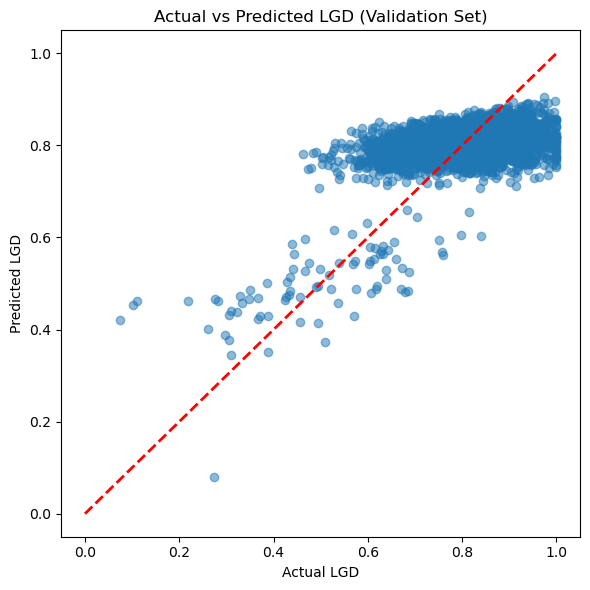

In [97]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_validation_beta,
    y_validation_pred,
    alpha=0.5
)

plt.plot(
    [0, 1],
    [0, 1],
    "r--",
    linewidth=2
)

plt.xlabel("Actual LGD")
plt.ylabel("Predicted LGD")
plt.title("Actual vs Predicted LGD (Validation Set)")

plt.tight_layout()
plt.show()


The model captures the overall relationship between actual and predicted LGD values. Most predictions are concentrated around the higher LGD range, reflecting the underlying distribution of the defaulted portfolio. Some underprediction of very high LGD values and overprediction of lower LGD values is observed, which is consistent with the model's moderate explanatory power (R² ≈ 0.31).

### Residual Analysis

In [98]:
validation_residuals = y_validation_beta - y_validation_pred

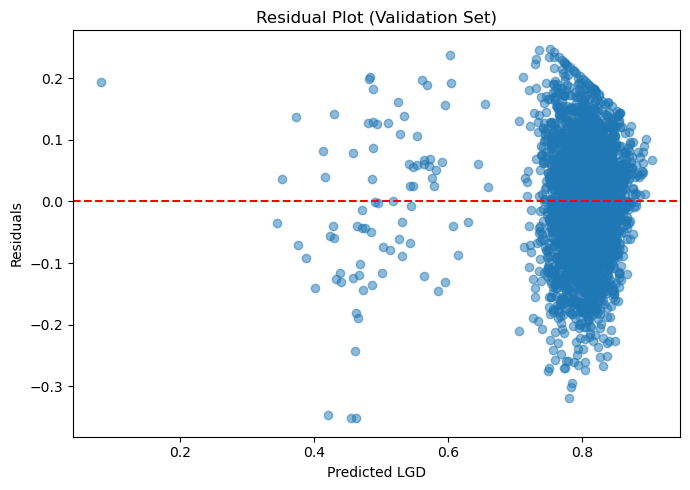

In [99]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_validation_pred,
    validation_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted LGD")
plt.ylabel("Residuals")
plt.title("Residual Plot (Validation Set)")

plt.tight_layout()
plt.show()

Residuals are centered around zero with no strong systematic pattern, suggesting the model does not exhibit significant bias. A wider spread is observed around the most common predicted LGD values (approximately 0.75–0.85), reflecting the concentration of observations in this region. A small number of outliers remain, but the overall residual distribution indicates an acceptable model fit.

### Feature Importance

In [100]:
coefficient_summary = pd.DataFrame({
    "Feature": beta_results.params.index,
    "Coefficient": beta_results.params.values,
    "P-value": beta_results.pvalues.values,
})

coefficient_summary["Absolute Coefficient"] = (
    coefficient_summary["Coefficient"].abs()
)


In [101]:
coefficient_summary = coefficient_summary.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coefficient_summary.head(20)

,Feature,Coefficient,P-value,Absolute Coefficient
75,precision,2.308449,0.000000e+00,2.308449
0,const,1.455913,0.000000e+00,1.455913
37,secured_flag,-0.217504,3.590081e-72,0.217504
23,b_util_ratio,-0.211857,2.137474e-146,0.211857
49,residence_type_cd_OTH,-0.121020,1.808602e-04,0.121020
55,state_cd_IL,-0.104473,2.242459e-03,0.104473
62,state_cd_PA,-0.102744,2.452800e-03,0.102744
70,d_curr_delinq_bucket_cd_150-179,0.101914,7.069439e-03,0.101914
54,state_cd_GA,-0.083954,1.248218e-02,0.083954
57,state_cd_MI,-0.081372,1.761135e-02,0.081372


In [102]:
significant_features = (
    coefficient_summary[
        coefficient_summary["P-value"] < 0.05
    ]
    .sort_values(
        by="Absolute Coefficient",
        ascending=False
    )
)

significant_features

,Feature,Coefficient,P-value,Absolute Coefficient
75,precision,2.308449,0.000000e+00,2.308449
0,const,1.455913,0.000000e+00,1.455913
37,secured_flag,-0.217504,3.590081e-72,0.217504
23,b_util_ratio,-0.211857,2.137474e-146,0.211857
49,residence_type_cd_OTH,-0.121020,1.808602e-04,0.121020
55,state_cd_IL,-0.104473,2.242459e-03,0.104473
62,state_cd_PA,-0.102744,2.452800e-03,0.102744
70,d_curr_delinq_bucket_cd_150-179,0.101914,7.069439e-03,0.101914
54,state_cd_GA,-0.083954,1.248218e-02,0.083954
57,state_cd_MI,-0.081372,1.761135e-02,0.081372


In [103]:
feature_importance = significant_features[
    ~significant_features["Feature"].isin(["const", "precision"])
]

feature_importance

,Feature,Coefficient,P-value,Absolute Coefficient
37,secured_flag,-0.217504,3.590081e-72,0.217504
23,b_util_ratio,-0.211857,2.137474e-146,0.211857
49,residence_type_cd_OTH,-0.121020,1.808602e-04,0.121020
55,state_cd_IL,-0.104473,2.242459e-03,0.104473
62,state_cd_PA,-0.102744,2.452800e-03,0.102744
70,d_curr_delinq_bucket_cd_150-179,0.101914,7.069439e-03,0.101914
54,state_cd_GA,-0.083954,1.248218e-02,0.083954
57,state_cd_MI,-0.081372,1.761135e-02,0.081372
65,state_cd_WA,-0.076495,2.460151e-02,0.076495
61,state_cd_OH,-0.075576,2.660579e-02,0.075576


**Key Findings:**

- `secured_flag` and `b_util_ratio` were the strongest predictors of LGD in the Beta Regression model.
- b_util_ratio had a negative coefficient (-0.212), meaning higher utilization was associated with lower LGD, a counterintuitive result worth flagging for further investigation
- Several state-level variables (state_cd_IL, state_cd_PA, state_cd_GA, etc.) were also statistically significant, suggesting geographic variation in recovery outcomes, potentially reflecting differences in collections/legal environments across states, though this warrants further investigation to confirm it isn't sampling noise.
- d_dpd_curr_cnt (-0.032) showed an opposite sign to d_curr_delinq_bucket_cd_150-179 (+0.102), despite both measuring delinquency severity likely a residual multicollinearity effect between correlated delinquency measures rather than a genuine reversal in relationship
- Delinquency-related variables (`d_curr_delinq_bucket_cd_150-179`, `d_dpd_curr_cnt`, `d_times_60dpd_12m_cnt`) were also statistically significant, highlighting the importance of repayment behavior.
- Balance and exposure variables (`collateral_value_amt`, `total_debt_amt`) contributed meaningfully to LGD prediction.
- Payment behaviour (`p_ontime_pay_12m_cnt`, `p_days_since_last_pay_cnt`) and recent credit inquiries (`inq_6m_cnt`, `inq_12m_cnt`) were also significant drivers.

In [104]:
lgd_predictions = oot_ids.copy()

lgd_predictions["lgd_pred"] = y_oot_pred

lgd_predictions.to_csv(
    "../data/processed/lgd_predictions.csv",
    index=False,
)


In [105]:
import pickle

imputation_values = {
    "emp_length_yrs": emp_length_median,
    "bureau_score_2": bureau_score_2_median,
    "p_days_since_last_pay_cnt": p_days_since_last_pay_median,
    "dti_ratio": dti_ratio_median,
    "d_mob_since_last_delinq_cnt": d_mob_since_last_delinq_median,
    "secured_collateral_value": secured_median,
}

lgd_pipeline = {
    "model": beta_results,
    "encoder": encoder,
    "scaler": scaler,
    "imputation_values": imputation_values,
    "encoder_features": encoder_features,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "continuous_features": continuous_features,
    "feature_order": X_train.columns.tolist(),
    "drop_columns_corr": drop_columns_corr,
    "vif_drop_columns": vif_drop_columns,
}

with open("../saved_objects/lgd_pipeline.pkl", "wb") as f:
    pickle.dump(lgd_pipeline, f)

## Conclusion

This project developed a Loss Given Default (LGD) model using a simulated credit card portfolio. The data underwent comprehensive preprocessing, including missing value treatment, feature selection, correlation analysis, multicollinearity assessment using VIF, and one-hot encoding of categorical variables. A Beta Regression model was selected because LGD is a continuous target bounded between 0 and 1.

The model initially faced convergence issues, which were resolved by standardizing the continuous variables before model fitting. Performance was evaluated on the training, validation, and out-of-time (OOT) datasets using MAE, RMSE, R², and Spearman correlation. The model achieved consistent performance across all three datasets (MAE ≈ 0.072, RMSE ≈ 0.091, R² ≈ 0.31–0.34), indicating good generalization with no significant overfitting.

Feature importance analysis identified credit utilization, secured status, delinquency behavior, collateral value, total debt, payment behavior, and recent credit inquiries as significant predictors of LGD. Overall, the project demonstrates an end-to-end LGD modeling workflow following industry practices, from data preparation through model development, validation, and interpretation.